# Random Variables and Basic Distributions

## Bernoulli and Binomial Distributions

The simplest type of random variable is a variable $X$ that takes on the value $1$ if a certain event occurs and $0$ otherwise. For instance assume that our sample space corresponds to rolling two six-sided dice and the event we are interest in is that the sum of the two dice is 5. 

$$
\begin{aligned}
\Omega &= \{(a, b) \, : \, a, b \in \{1, 2, 3, 4, 5, 6\}\}\\
F &= \{(a, b) \, : \, a+b=5\}\\
X(\omega) &= \begin{cases}
1 & \text{, if }\omega \in F\\
0 & \text{, otherwise}
\end{cases} 
\end{aligned}
$$

$$
X \sim \mathrm{Ber}(p)
$$

$$
p(x) = \begin{cases}
p &, \text{if } x=1\\
1-p &, \text{if } x=0
\end{cases}
$$

If $K = B_1 + \dots + B_n$ with independent Bernoulli random variables $B_i \sim \mathrm{Ber}(p)$ then we say that $K$ is binomially distributed with $n$ trials and success probability $p$ and write
$$
K \sim \mathrm{Bin}(n, p) \enspace .
$$

In [2]:
import numpy as np

rng = np.random.default_rng(seed=0)
y = rng.binomial(20, 0.2, size=20)
y

array([5, 3, 1, 1, 6, 6, 4, 5, 4, 7, 6, 0, 6, 1, 5, 2, 6, 4, 3, 4])

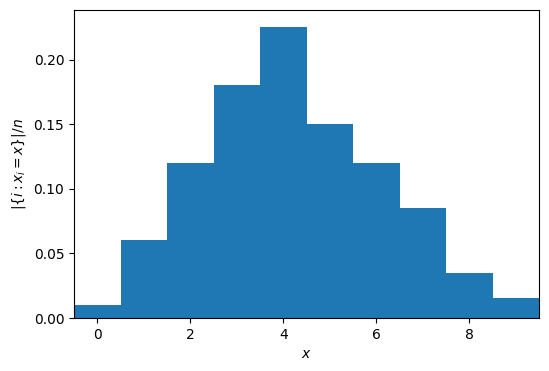

In [3]:
from matplotlib import pyplot as plt
from plotting import histo_1d

y = rng.binomial(20, 0.2, size=200)
fig, ax = plt.subplots(figsize=(6,4))
histo_1d(ax, y)
# ax.hist(y, np.arange(y.min() - 0.5, y.max() + 1.5), density=True, align='mid')
# ax.margins(x=0)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$|\{i: x_i = x\}|/n$')
plt.show()

In this case, the distribution of $K$ is given by the probability mass function
$$
f(k) = {n \choose k} p^k (1-p)^{n-k} 
$$
where
$$
{n \choose k} = \frac{n!}{(n-k)!\,k!}
$$
is the binomial coefficient.

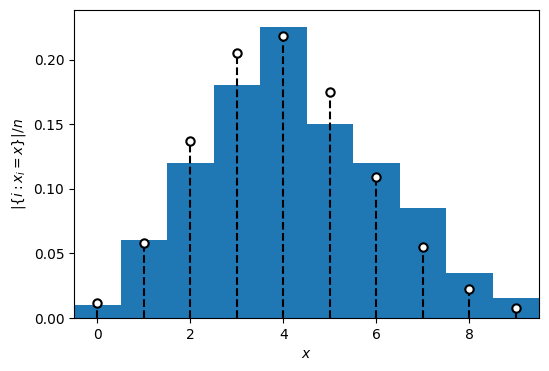

In [4]:
from scipy.special import comb
from plotting import histo_1d

def binom_pmf(n, p):
    def pmf(x):
        return comb(n, x)*p**x*(1-p)**(n-x)
    return pmf

# x = np.arange(y.min(), y.max()+1)
# p = binom_pmf(20, 0.2)(x)

fig, ax = plt.subplots(figsize=(6, 4))
histo_1d(ax, y, binom_pmf(20, 0.2))
# ax.hist(y, np.arange(y.min() - 0.5, y.max() + 1.5), density=True, align='mid')
# ax.vlines(x, 0, p, colors='k', linestyles='--')
# ax.scatter(x, p, facecolors='white', linewidths=1.5, edgecolors='k', zorder=3)
# ax.set_ylim(ax.get_ylim()*np.array([0, 1.01]))
# ax.margins(x=0)
# ax.set_xlabel('$x$')
# ax.set_ylabel(r'$|\{i: x_i = x\}|/n$')
plt.show()
# comb(10, np.array([1, 2, 3]))

In [5]:
for i, n in enumerate()
for m, p in zip([20, 200, 2000], [0.2, 0.02, 0.002]):
    y = rng.binomial(m, p, size=[100, 100, 100])
y

SyntaxError: expected ':' (490861876.py, line 1)

## Continuous Uniform Distribution

$$
X \sim \mathrm{Unif}(a, b)
$$

$$
p(x) =
\begin{cases}
0 &, \text{if } x \leq a\\
1/(b-a) &, \text{if } x \in (a, b]\\
0 &, \text{otherwise}
\end{cases}
$$

## Beta Distribution

Let $X$ and $Y$ two independent Gamma random variables with the same rate parameter, i.e., $X \sim \mathrm{Gamma}(\alpha, \lambda)$ and $Y \sim \mathrm{Gamma}(\beta, \lambda)$. Then the ratio
$$
R = \frac{X}{X+Y}
$$
is called a **Beta** random variable with shape parameters $\alpha>0$ and $\beta>0$, denoted $R \sim \mathrm{Beta}(\alpha, \beta)$, and is described by the probability density function
$$
p(r) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} r^{\alpha-1} (1-r)^{\beta-1} \enspace .
$$

To find the pdf of $R$, we can transform the joint pdf of $X$ and $Y$ to the joint pdf of $T=X + Y$ and $R=X/(X+Y)$ and then use the law of total probability to find the marginal pdf of $R$.
Technically, the first step is described by
$$
\begin{aligned}
p_{T, R}(t, r) = p_{X, Y}(x(t, r), y(t, r)) \left| J_{t, r}(x,y) \right |
\end{aligned}
$$
with the change of variables $t(x,y) = x + y$, $r(x,y) = x / (x + y)$, inverse transformations
$$
\begin{aligned}
x(t, r)&=rt\\
y(t, r)&=(1-r)t
\end{aligned}
$$
and the Jacobian matrix
$$
J_{t, r}(x,y) = \begin{bmatrix} \partial x/\partial t & \partial x/\partial r \\ \partial t/\partial x & \partial t/\partial y\end{bmatrix} = \begin{bmatrix} r & t \\ 1-r & -t\end{bmatrix} \enspace .
$$
Plugging in the Jacobian determinant 
$$
\left| J_{t, r}(x,y) \right | = |-rt - (1-r)t| = |rt - (r+1)t| = t 
$$
into the above expression, we arrive at the joint pdf
$$
\begin{aligned}
p_{T,R}(t, r) &= \frac{1}{\Gamma(\alpha)} x^{\alpha-1} \exp(-x) \frac{1}{\Gamma(\beta)} y^{\beta - 1} \exp(-y) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1} y^{\beta - 1} \exp(-(x+y)) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} (rt)^{\alpha-1} ((1-r)t)^{\beta - 1} \exp(-t) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} t^{\alpha+\beta-1} \exp(-t) \, r^{\alpha-1}(1-r)^{\beta - 1} \enspace .
\end{aligned}
$$
From there, we can find the marginal via the law of total probability
$$
\begin{aligned}
p_{R}(r) &= \int_0^\infty p_{T, R}(t, r) \mathrm{d} t \\
&= \frac{1}{\Gamma(\alpha)\Gamma(\beta)}  \underbrace{\int_0^\infty t^{\alpha+\beta-1} \exp(-t) \mathrm{d}t}_{\Gamma(\alpha+\beta)} \,r^{\alpha-1}(1-r)^{\beta - 1} \\
&= \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} r^{\alpha-1}(1-r)^{\beta - 1} \enspace .
\end{aligned}
$$

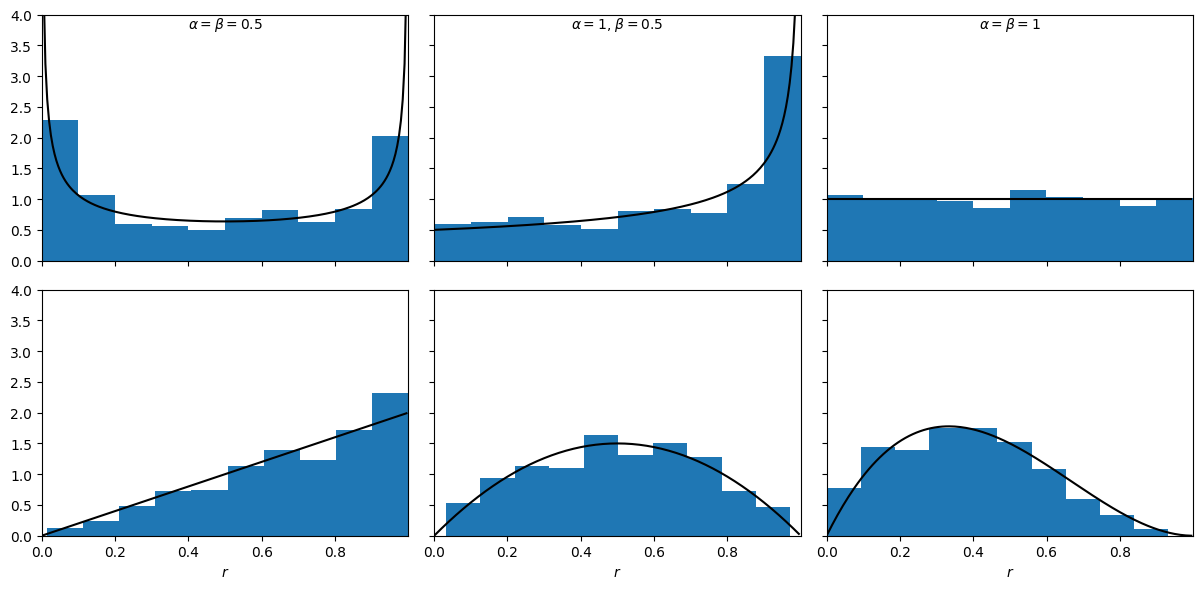

In [62]:
from scipy.special import beta as beta_fct
from scipy.stats import beta

def beta_pdf(x, alpha, beta):
    return x**(alpha-1)*(1-x)**(beta-1)/beta_fct(alpha, beta)

x = np.linspace(0, 1, 200, endpoint=False)
# print(beta_pdf(x, 0.5, 0.5))

n = 500
r_05_05 = rng.beta(0.5, 0.5, size=n)
r_1_05 = rng.beta(1, 0.5, size=n)
r_1_1 = rng.beta(1, 1, size=n)
r_2_1 = rng.beta(2, 1, size=n)
r_2_2 = rng.beta(2, 2, size=n)
r_2_3 = rng.beta(2, 3, size=n)
# print(r_0505)

fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharey=True, sharex=True, tight_layout=True)

ax[0][0].hist(r_05_05, density=True)
ax[0][0].set_xmargin(0)
# ax[0].plot(x, beta_pdf(x, 0.5, 0.5))
ax[0][0].plot(x, beta.pdf(x, 0.5, 0.5), color='k')
ax[0][0].text(0.5, 1, r'$\alpha=\beta=0.5$', transform=ax[0][0].transAxes, horizontalalignment='center', verticalalignment='top')

ax[0][1].hist(r_1_05, density=True)
ax[0][1].plot(x, beta.pdf(x, 1, 0.5), color='k')
ax[0][1].set_xmargin(0)
ax[0][1].text(0.5, 1, r'$\alpha=1$, $\beta=0.5$', transform=ax[0][1].transAxes, horizontalalignment='center', verticalalignment='top')

ax[0][2].hist(r_1_1, density=True)
ax[0][2].plot(x, beta.pdf(x, 1, 1), color='k')
ax[0][2].set_xmargin(0)
ax[0][2].text(0.5, 1, r'$\alpha=\beta=1$', transform=ax[0][2].transAxes, horizontalalignment='center', verticalalignment='top')

ax[1][0].hist(r_2_1, density=True)
ax[1][0].plot(x, beta.pdf(x, 2, 1), color='k')
ax[1][0].set_xmargin(0)

ax[1][1].hist(r_2_2, density=True)
ax[1][1].plot(x, beta.pdf(x, 2, 2), color='k')
ax[1][1].set_xmargin(0)

ax[1][2].hist(r_2_3, density=True)
ax[1][2].plot(x, beta.pdf(x, 2, 3), color='k')
ax[1][2].set_xmargin(0)

ax[0][0].set_ylim(0, 4)
ax[1][0].set_xlabel('$r$')
ax[1][1].set_xlabel('$r$')
ax[1][2].set_xlabel('$r$')


plt.show()